In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

df = pd.read_csv('creditcard.csv')
df.head() #display the first 5 rows

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [2]:
#checking structures and missing values

print(f"Dataset shape: {df.shape}\n")
df.info()

Dataset shape: (284807, 31)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-

In [3]:
#summary statistics for non-PCA features
df[['Time', 'Amount', 'Class']].describe()

,Time,Amount,Class
count,284807.000000,284807.000000,284807.000000
mean,94813.859575,88.349619,0.001727
std,47488.145955,250.120109,0.041527
min,0.000000,0.000000,0.000000
25%,54201.500000,5.600000,0.000000
50%,84692.000000,22.000000,0.000000
75%,139320.500000,77.165000,0.000000
max,172792.000000,25691.160000,1.000000


C:\Users\kdwiv\AppData\Local\Temp\ipykernel_41436\634431796.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, palette = 'pastel')


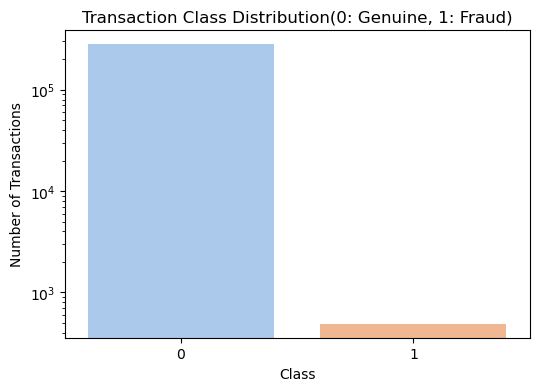

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


In [5]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=df, palette = 'pastel')
plt.title('Transaction Class Distribution(0: Genuine, 1: Fraud)')
plt.xlabel('Class')
plt.ylabel('Number of Transactions')
plt.yscale('log')
plt.show()

print(df['Class'].value_counts(normalize=True) * 100) #percentage of each class

In [6]:
print("--- Genuine Transactions ---")
print(df[df['Class'] == 0]['Amount'].describe())

print("\n--- Fraudulent Transactions ---")
print(df[df['Class'] == 1]['Amount'].describe())

--- Genuine Transactions ---
count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

--- Fraudulent Transactions ---
count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64


C:\Users\kdwiv\AppData\Local\Temp\ipykernel_41436\824992062.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = 'Class', y = 'Amount', data = df, showfliers = False, palette = 'Set2')


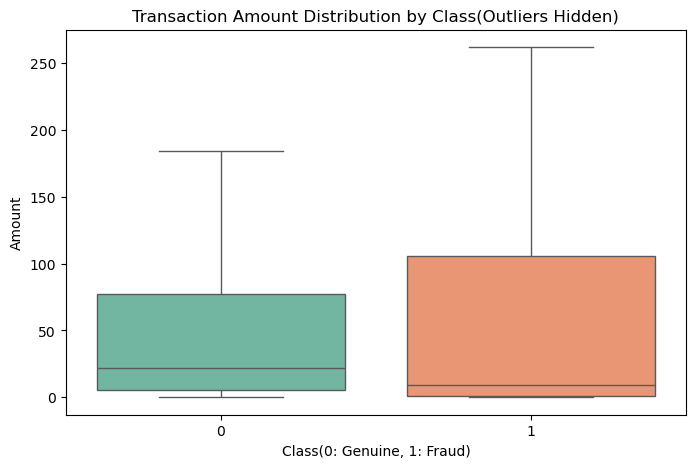

In [7]:
#visualizing amount distribution
plt.figure(figsize=(8, 5))
sns.boxplot(x = 'Class', y = 'Amount', data = df, showfliers = False, palette = 'Set2')
plt.title('Transaction Amount Distribution by Class(Outliers Hidden)')
plt.xlabel('Class(0: Genuine, 1: Fraud)')
plt.ylabel('Amount')
plt.show()


C:\Users\kdwiv\AppData\Local\Temp\ipykernel_41436\3229459451.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['Class'] == 0]['Time'], label = 'Genuine', shade = True, color = 'blue')
C:\Users\kdwiv\AppData\Local\Temp\ipykernel_41436\3229459451.py:5: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['Class'] == 1]['Time'], label = 'Fraudulent', shade = True, color = 'red')


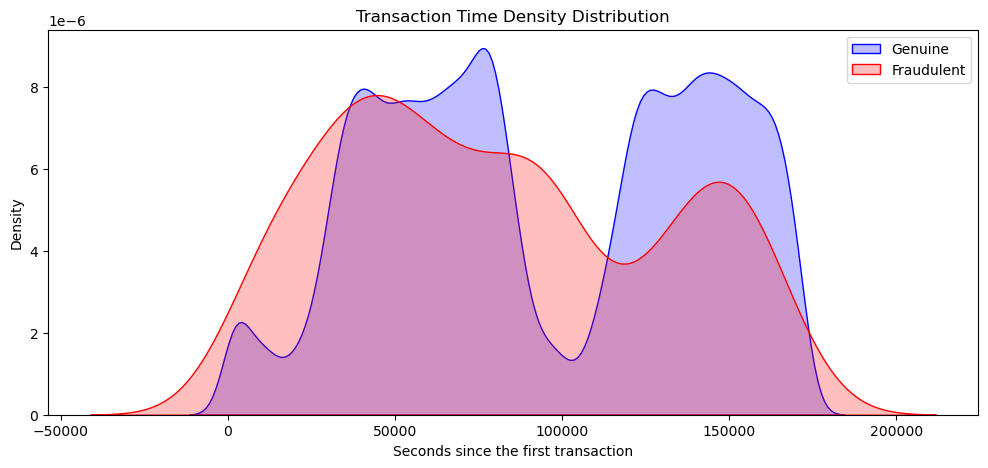

In [8]:
#Analyzing the Time Feature

plt.figure(figsize=(12, 5))
sns.kdeplot(df[df['Class'] == 0]['Time'], label = 'Genuine', shade = True, color = 'blue')
sns.kdeplot(df[df['Class'] == 1]['Time'], label = 'Fraudulent', shade = True, color = 'red')
plt.title('Transaction Time Density Distribution')
plt.xlabel('Seconds since the first transaction')
plt.ylabel('Density')
plt.legend()
plt.show()

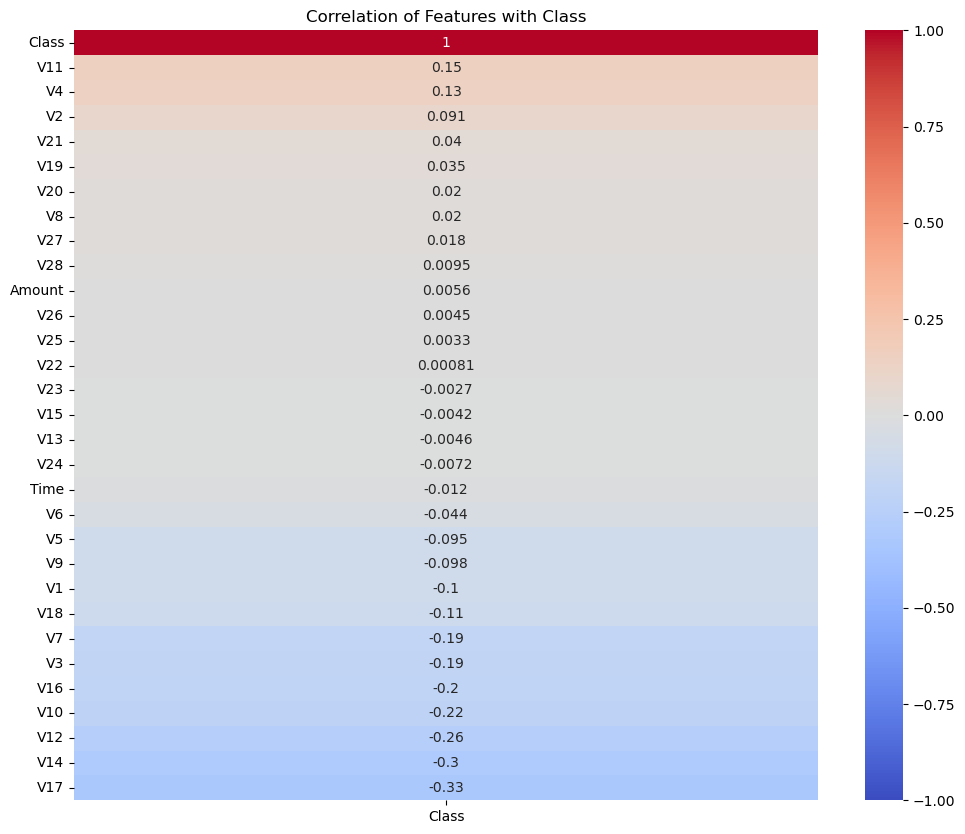

In [9]:
#feature correlation matrix 

plt.figure(figsize=(12, 10))
corr = df.corr()

sns.heatmap(corr[['Class']].sort_values(by='Class', ascending=False), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation of Features with Class')
plt.show()

In [11]:
import sys
!{sys.executable} -m pip install xgboost

   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   -- ------------------------------------- 3.9/69.5 MB 21.5 MB/s eta 0:00:04
   ----- ---------------------------------- 10.0/69.5 MB 24.7 MB/s eta 0:00:03
   --------- ------------------------------ 15.7/69.5 MB 25.5 MB/s eta 0:00:03
   ------------ --------------------------- 21.0/69.5 MB 25.7 MB/s eta 0:00:02
   --------------- ------------------------ 27.0/69.5 MB 26.0 MB/s eta 0:00:02
   ------------------ --------------------- 32.2/69.5 MB 26.2 MB/s eta 0:00:02
   --------------------- ------------------ 38.0/69.5 MB 26.3 MB/s eta 0:00:02
   ------------------------- -------------- 44.0/69.5 MB 26.5 MB/s eta 0:00:01
   ---------------------------- ----------- 49.5/69.5 MB 26.4 MB/s eta 0:00:01
   ------------------------------- -------- 55.3/69.5 MB 26.5 MB/s eta 0:00:01
   ---------------------------------- ----- 60.8/69.5 MB 26.4 MB/s eta 0:00:01
   ------------------------------------- -- 65.5/69.5 MB 26.1 

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve


#Scale the un-scaled features

scaler = RobustScaler()
df['scaled_amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
df['scaled_time'] = scaler.fit_transform(df['Time'].values.reshape(-1, 1))

X = df.drop(['Time','Amount','Class'], axis=1)
y = df['Class']

#Drop the original time and amount\

X = df.drop(['Time', 'Amount', 'Class'], axis=1)
y = df['Class']

#2.Stratified train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
    )

#3. Calculate XGBoost scale_pos_weight
neg_count, pos_count = np.bincount(y_train)
weight_ratio = neg_count / pos_count

#4. Initialize the models with Imbalance Handling
rf_model = RandomForestClassifier(n_estimators = 100, class_weight = 'balanced', random_state = 42, n_jobs = -1)
xgb_model = XGBClassifier(scale_pos_weight = weight_ratio, random_state = 42, eval_metric = 'logloss')


In [14]:
import sys
!{sys.executable} -m pip install numpy

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, auc
import numpy as np 

#preprocessing 

scaler = RobustScaler()
df['scaled_amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
df['scaled_time'] = scaler.fit_transform(df['Time'].values.reshape(-1, 1))

X = df.drop(['Time', 'Amount', 'Class'], axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

neg_count, pos_count = np.bincount(y_train)
weight_ratio = neg_count / pos_count

#training and evaluation

rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
xgb_model = XGBClassifier(scale_pos_weight=weight_ratio, random_state=42, eval_metric='logloss')

#training random forest model

print("Training Random Forest Classifier...")
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

#train xgboost

print("Training XGBoost Classifier...")
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

#Print Evaluation Reports
print("/n" + "="*20 + "RANDOM FOREST REPORT" + "="*20)
print(classification_report(y_test, rf_preds))

print("/n" + "="*20 + "XGBOOST REPORT" + "="*20)
print(classification_report(y_test, xgb_preds))


Training Random Forest Classifier...
Training XGBoost Classifier...
/n====================RANDOM FOREST REPORT====================
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.76      0.85        98

    accuracy                           1.00     56962
   macro avg       0.98      0.88      0.92     56962
weighted avg       1.00      1.00      1.00     56962

/n====================XGBOOST REPORT====================
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.89      0.83      0.86        98

    accuracy                           1.00     56962
   macro avg       0.94      0.91      0.93     56962
weighted avg       1.00      1.00      1.00     56962



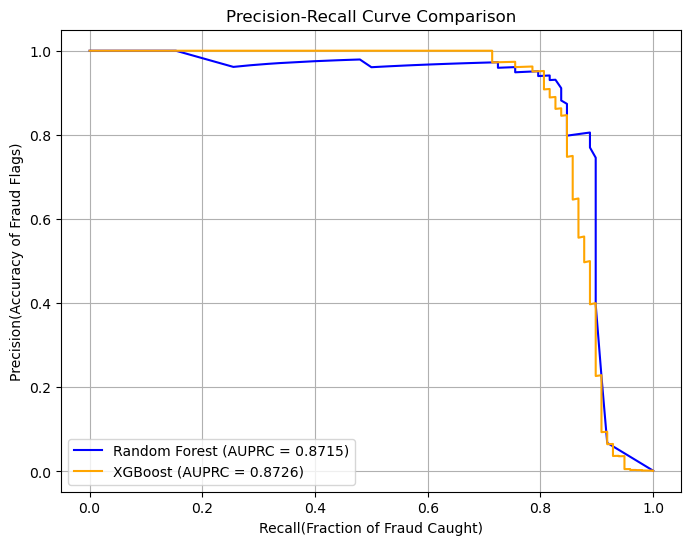

Random Forest AUPRC: 0.8715
XGBoost AUPRC: 0.8726


In [17]:
#area under the precision-recall curve
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc

#get probabilities for the positive class (fraudulent transactions)
rf_probs = rf_model.predict_proba(X_test)[:, 1]
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

#calculate precision-recall curve and AUC for Random Forest
rf_precision, rf_recall, _ = precision_recall_curve(y_test, rf_probs)
xgb_precision, xgb_recall, _ = precision_recall_curve(y_test, xgb_probs)

#calculate area under the curve (AUC) for both models
rf_auprc = auc(rf_recall, rf_precision)
xgb_auprc = auc(xgb_recall, xgb_precision)

#plotting
plt.figure(figsize=(8, 6))
plt.plot(rf_recall, rf_precision, label=f'Random Forest (AUPRC = {rf_auprc:.4f})', color='blue')
plt.plot(xgb_recall, xgb_precision, label=f'XGBoost (AUPRC = {xgb_auprc:.4f})', color='orange')

plt.xlabel('Recall(Fraction of Fraud Caught)')
plt.ylabel('Precision(Accuracy of Fraud Flags)')
plt.title('Precision-Recall Curve Comparison')
plt.legend()
plt.grid(True)
plt.show()

print(f"Random Forest AUPRC: {rf_auprc:.4f}")
print(f"XGBoost AUPRC: {xgb_auprc:.4f}")


In [18]:
#installing joblib for loading it later through fastapi

import sys
!{sys.executable} -m pip install joblib


In [ ]:
import joblib

#saving the xgboost model
model_filename = 'xgb_fraud_model.pkl'
joblib.dump(xgb_model, model_filename)
print(f"Model saved to {model_filename}")

#save the robust scaler
scaler_filename = 'robust_scaler.pkl'
joblib.dump(scaler, scaler_filename)
print(f"Scaler saved to {scaler_filename}")


Model saved to xgb_fraud_model.pkl
Scaler saved to robust_scaler.pkl


In [20]:
loaded_model = joblib.load(model_filename)
loaded_scaler = joblib.load(scaler_filename)

test_row = X_test.iloc[[0]]
prediction = loaded_model.predict(test_row)

print(f"Verification Successful! Prediction Label:{prediction[0]}")


Verification Successful! Prediction Label:0
